<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_6_10_4_Principal_Components_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 6 - 10.4 Principal Components Analysis
###STATS 302 Principle of Machine Learning
###Duke Kunshan University

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# from google.colab import files
import io

# 10.4 Lab 1: Principal Components Analysis

In [6]:
#load the data
data = pd.read_csv(r'D:\UG Files\Year 4\S3\STATS 302\Codes\STATS-302-Intro-to-ML\Week_6\Week_6_Data\USArrests.csv')
data = data.rename(columns={data.columns[0]: "Name"})
print(data.shape)
data.head()

# loading the dataset
# uploaded = files.upload()
# data = pd.read_csv(io.BytesIO(uploaded['USArrests.csv']))
# print(data.shape)
# data.head()

(50, 5)


,Name,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


This data contains states of US
- Name  - name of the states
- Murder - number of arrests for murder per million pop.
- Assault - number of arrests for assaults per million pop.
- Urbanpop - percentage of population living in urban area
- Rape - number of rape cases per million population

In [7]:
states = data.iloc[:,0]
#names of the states in alphabatical order
print(states)

0            Alabama
1             Alaska
2            Arizona
3           Arkansas
4         California
5           Colorado
6        Connecticut
7           Delaware
8            Florida
9            Georgia
10            Hawaii
11             Idaho
12          Illinois
13           Indiana
14              Iowa
15            Kansas
16          Kentucky
17         Louisiana
18             Maine
19          Maryland
20     Massachusetts
21          Michigan
22         Minnesota
23       Mississippi
24          Missouri
25           Montana
26          Nebraska
27            Nevada
28     New Hampshire
29        New Jersey
30        New Mexico
31          New York
32    North Carolina
33      North Dakota
34              Ohio
35          Oklahoma
36            Oregon
37      Pennsylvania
38      Rhode Island
39    South Carolina
40      South Dakota
41         Tennessee
42             Texas
43              Utah
44           Vermont
45          Virginia
46        Washington
47     West V

In [14]:
X = data.iloc[:,1:]
print(list(X.columns))
X.head()

['Murder', 'Assault', 'UrbanPop', 'Rape']


,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


In [9]:
X.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


We can see from the above table that they have irregular ranges, and assault has the highest value of mean and also std (also variance which is square of std)

So, if we apply PCA to this data, it will give the highest priority to assault, and to avoid this, we will be scaling the data.

In [15]:
# scaling the data, Mean = 0, Standard deviation = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled_df = pd.DataFrame(X_scaled,columns = X.columns)
X_scaled_df.head()

,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


In [17]:
X_scaled_df.describe()

,Murder,Assault,UrbanPop,Rape
count,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01
mean,-7.105427e-17,1.387779e-16,-4.396483e-16,8.593126e-16
std,1.010153e+00,1.010153e+00,1.010153e+00,1.010153e+00
min,-1.620693e+00,-1.524362e+00,-2.340661e+00,-1.502548e+00
25%,-8.611383e-01,-7.486054e-01,-7.704502e-01,-6.640245e-01
50%,-1.247758e-01,-1.425453e-01,3.210209e-02,-1.220847e-01
75%,8.029251e-01,9.483628e-01,8.521012e-01,5.330962e-01
max,2.229265e+00,2.015028e+00,1.776781e+00,2.671197e+00


In [18]:
# using pca to get principal components
pca = PCA(n_components=4)
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [20]:
#loading vectors: how much that original feature contributes to a principal component.
pd.DataFrame(pca.components_,columns = X.columns,index = ['PC_1','PC_2','PC_3','PC_4']).T

,PC_1,PC_2,PC_3,PC_4
Murder,0.535899,-0.418181,-0.341233,-0.649228
Assault,0.583184,-0.187986,-0.268148,0.743407
UrbanPop,0.278191,0.872806,-0.378016,-0.133878
Rape,0.543432,0.167319,0.817778,-0.089024


From the above table we can see the loding vectors as combinations of each principal components

In [21]:
# getting the points in principal components
pca_components = pca.transform(X_scaled)  # where each sample lies in the new principal component coordinate system
print(pca_components.shape)
df = pd.DataFrame(pca_components,columns = ['PC_1','PC_2','PC_3','PC_4'])
df.head()

(50, 4)


,PC_1,PC_2,PC_3,PC_4
0,0.985566,-1.133392,-0.444269,-0.156267
1,1.950138,-1.073213,2.040003,0.438583
2,1.763164,0.745957,0.054781,0.834653
3,-0.141420,-1.119797,0.114574,0.182811
4,2.523980,1.542934,0.598557,0.341996


In [22]:
print(list(data.iloc[:,0]))

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


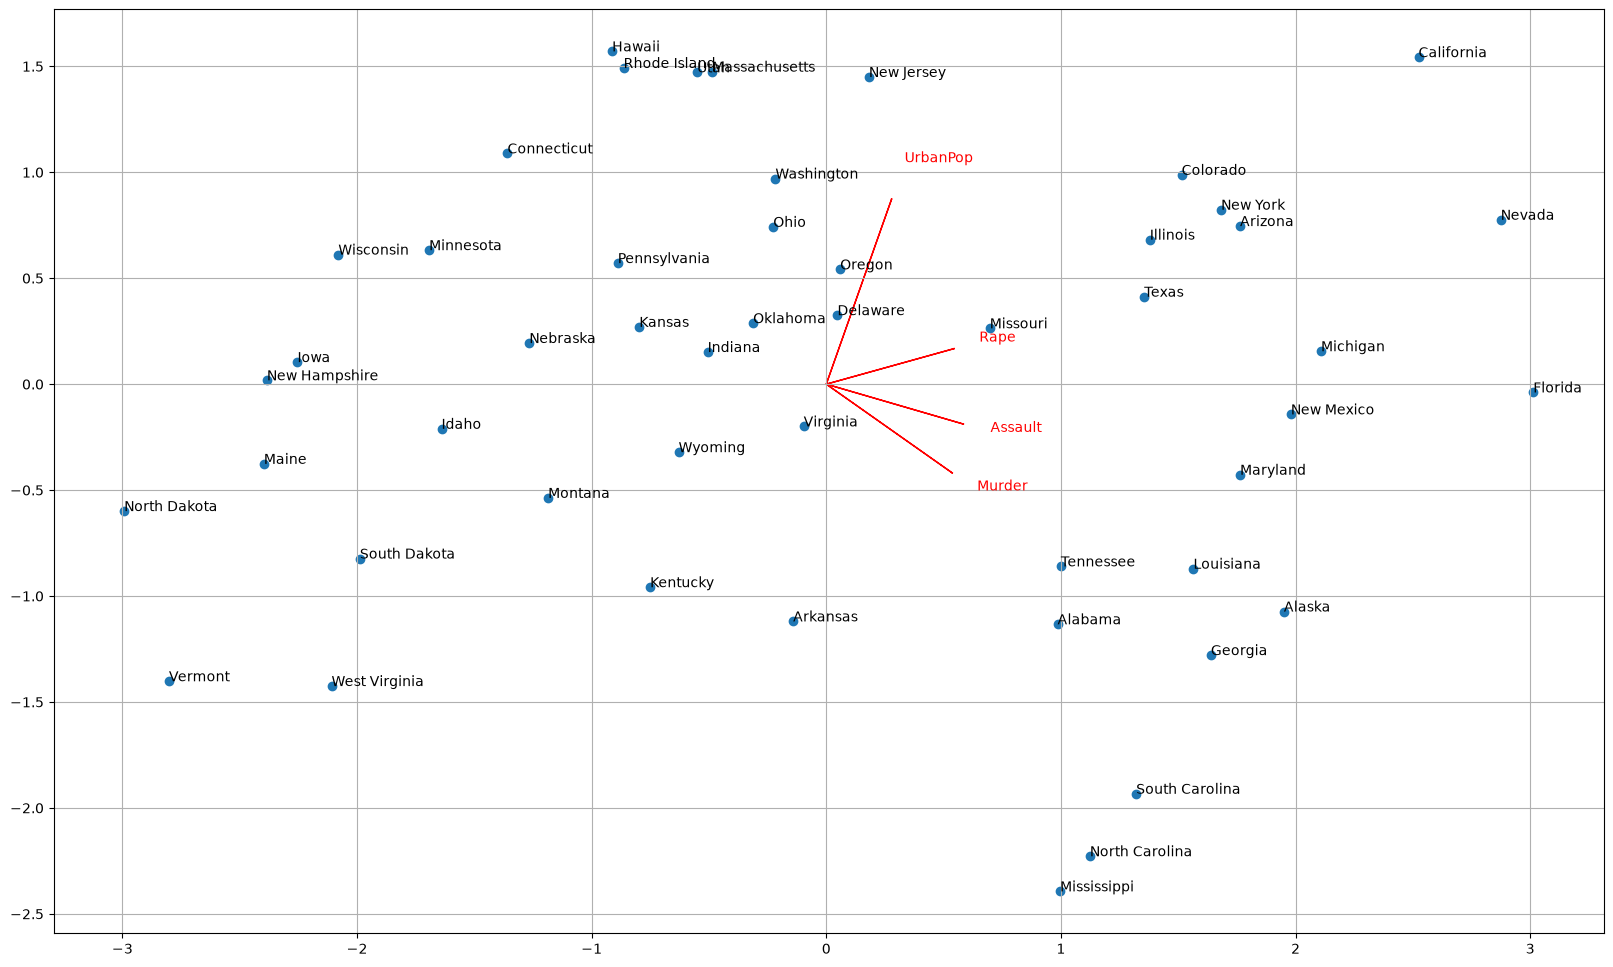

In [23]:
# biplot
fig, ax = plt.subplots(figsize = (20,12))
ax.grid(True)
ax.scatter(df['PC_1'],df['PC_2'])

names = list(data.iloc[:,0])

for i, txt in enumerate(names):
    ax.annotate(txt, (df['PC_1'][i], df['PC_2'][i]))  # annotatte the name of the cities

xvector = pca.components_[0] # see 'prcomp(my_data)$rotation' in R
yvector = pca.components_[1]

xs = pca.transform(X_scaled)[:,0] # see 'prcomp(my_data)$x' in R
ys = pca.transform(X_scaled)[:,1]


## visualize projections

## Note: scale values for arrows and text are a bit inelegant as of now,
##       so feel free to play around with them

for i in range(len(xvector)):
# arrows project features (ie columns from csv) as vectors onto PC axes
    plt.arrow(0, 0, xvector[i], yvector[i],
              color='r', width=0.0005, head_width=0.0025)
    plt.text(xvector[i]*1.2, yvector[i]*1.2,
             list(X.columns.values)[i], color='r')

In [24]:
# variance explained by each pc's: the variance of the transformed data along each principal component.
pca.explained_variance_

array([2.53085875, 1.00996444, 0.36383998, 0.17696948])

In [25]:
# variance explained ratio's: ratio percentage of the variances
pca.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

So, the first pc explaines 2.53 units of variance, which is around 62% of the total variance, the second pc expains 24.7 % of the variance in the data

<Axes: >

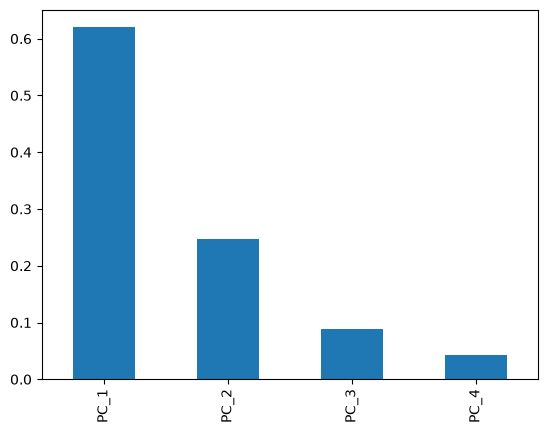

In [26]:
pd.Series(pca.explained_variance_ratio_,index = ['PC_1','PC_2','PC_3','PC_4']).plot.bar()

<Axes: >

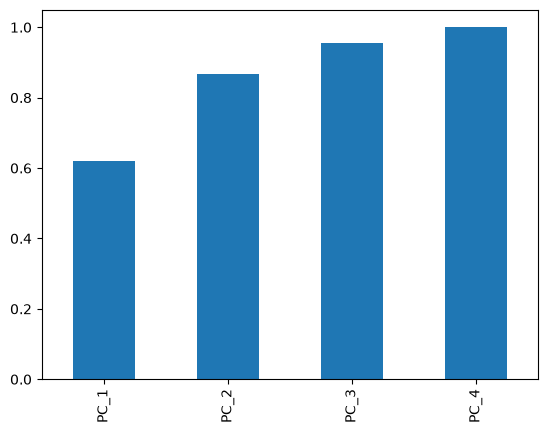

In [27]:
# culmulative sum of the variances of the pcs
pd.Series(np.cumsum(pca.explained_variance_ratio_),index = ['PC_1','PC_2','PC_3','PC_4']).plot.bar()